In [ ]:
import os
import pandas as pd
import numpy as np
from pprint import pprint

csv_path = "D:\\DS Assignment\\Neural networks\\Neural networks\\Alphabets_data.csv"   
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Dataset not found at {csv_path}. Upload or set correct path.")

df = pd.read_csv(csv_path)
print("Shape:", df.shape)
print("Columns:", list(df.columns))
display(df.head())
print("\nMissing per column:")
display(df.isnull().sum())



Shape: (20000, 17)
Columns: ['letter', 'xbox', 'ybox', 'width', 'height', 'onpix', 'xbar', 'ybar', 'x2bar', 'y2bar', 'xybar', 'x2ybar', 'xy2bar', 'xedge', 'xedgey', 'yedge', 'yedgex']


,letter,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10



Missing per column:


letter    0
xbox      0
ybox      0
width     0
height    0
onpix     0
xbar      0
ybar      0
x2bar     0
y2bar     0
xybar     0
x2ybar    0
xy2bar    0
xedge     0
xedgey    0
yedge     0
yedgex    0
dtype: int64

In [ ]:
possible_targets = ["label", "target", "class", "alphabet", "letter", "y"]
target_col = None
for t in possible_targets:
    if t in df.columns:
        target_col = t
        break
if target_col is None:
    target_col = df.columns[-1]   

print("Using target column:", target_col)
print("Class distribution:")
display(df[target_col].value_counts())


Using target column: letter
Class distribution:


letter
U    813
D    805
P    803
T    796
M    792
A    789
X    787
Y    786
N    783
Q    783
F    775
G    773
E    768
B    766
V    764
L    761
R    758
I    755
O    753
W    752
S    748
J    747
K    739
C    736
H    734
Z    734
Name: count, dtype: int64

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

for col in X.select_dtypes(exclude=[np.number]).columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = list(le.classes_)
print("Classes:", class_names)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print("Processed X shape:", X_scaled.shape, "y shape:", y_encoded.shape)


Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Processed X shape: (20000, 16) y shape: (20000,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.20, stratify=y_encoded, random_state=42
)
X_train_base, X_val, y_train_base, y_val = train_test_split(
    X_train, y_train, test_size=0.125, stratify=y_train, random_state=42
)  

print("Train_base:", X_train_base.shape, "Val:", X_val.shape, "Test:", X_test.shape)



Train_base: (14000, 16) Val: (2000, 16) Test: (4000, 16)


In [ ]:
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Input
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping

    tf.random.set_seed(42)
    n_features = X_train_base.shape[1]
    n_classes = len(class_names)

    model = Sequential([
        Input(shape=(n_features,)),
        Dense(64, activation="relu"),
        Dense(n_classes, activation="softmax")
    ])

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    history = model.fit(X_train_base, y_train_base,
                        validation_data=(X_val, y_val),
                        epochs=30, batch_size=32, callbacks=[es], verbose=2)

    print("Evaluate on test:")
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print("Test accuracy:", test_acc)
except Exception as e:
    print("TensorFlow/Keras not available or import failed. Error:", e)
    print("If you want to use Keras, install TensorFlow (pip install tensorflow) or use the sklearn fallback in next cell.")


Epoch 1/30
438/438 - 3s - 7ms/step - accuracy: 0.4693 - loss: 2.0722 - val_accuracy: 0.6720 - val_loss: 1.3300
Epoch 2/30
438/438 - 1s - 3ms/step - accuracy: 0.7197 - loss: 1.0793 - val_accuracy: 0.7410 - val_loss: 0.9583
Epoch 3/30
438/438 - 1s - 3ms/step - accuracy: 0.7733 - loss: 0.8404 - val_accuracy: 0.7725 - val_loss: 0.8088
Epoch 4/30
438/438 - 1s - 3ms/step - accuracy: 0.8069 - loss: 0.7178 - val_accuracy: 0.8030 - val_loss: 0.7154
Epoch 5/30
438/438 - 2s - 6ms/step - accuracy: 0.8249 - loss: 0.6353 - val_accuracy: 0.8215 - val_loss: 0.6480
Epoch 6/30
438/438 - 1s - 3ms/step - accuracy: 0.8420 - loss: 0.5741 - val_accuracy: 0.8310 - val_loss: 0.5959
Epoch 7/30
438/438 - 1s - 3ms/step - accuracy: 0.8557 - loss: 0.5260 - val_accuracy: 0.8415 - val_loss: 0.5537
Epoch 8/30
438/438 - 1s - 3ms/step - accuracy: 0.8634 - loss: 0.4864 - val_accuracy: 0.8515 - val_loss: 0.5185
Epoch 9/30
438/438 - 1s - 3ms/step - accuracy: 0.8729 - loss: 0.4530 - val_accuracy: 0.8615 - val_loss: 0.4885
E

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test accuracy: 0.92775

Classification report:
              precision    recall  f1-score   support

           A       0.96      0.96      0.96       158
           B       0.85      0.93      0.89       153
           C       0.95      0.97      0.96       147
           D       0.92      0.92      0.92       161
           E       0.91      0.90      0.91       154
           F       0.92      0.90      0.91       155
           G       0.94      0.93      0.94       155
           H       0.83      0.84      0.83       147
           I       0.97      0.89      0.93       151
           J       0.92      0.94      0.93       149
           K       0.90      0.92      0.91       148
           L       0.93      0.94      0.93       152
           M       0.99      0.95      0.97       158
           N       0.92      0.92      0.92       157
           O       0.95      0.91      0.93       150
           P       0.93      0.94      0.94    

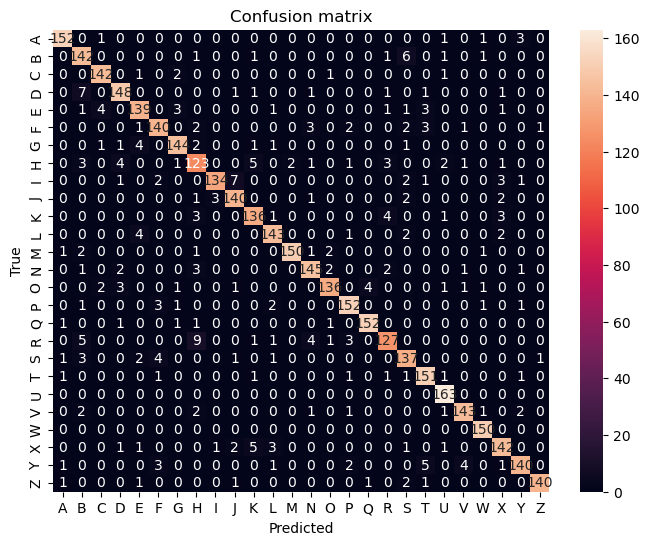

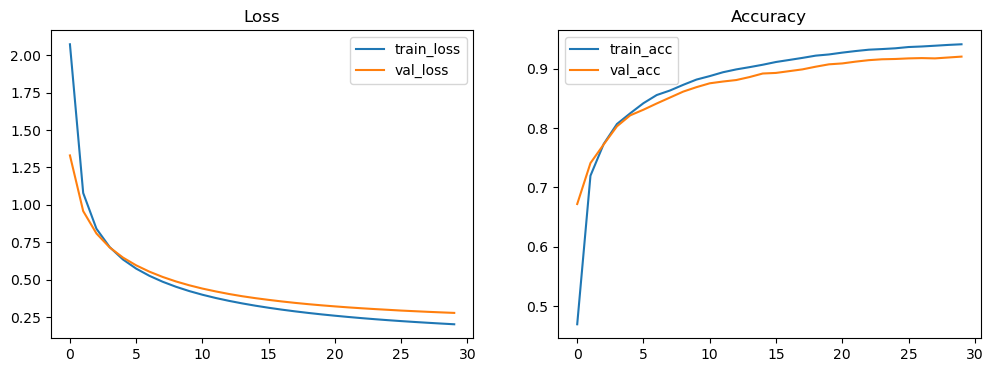

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

if 'model' in globals():
    y_pred_prob = model.predict(X_test)
    y_pred = np.argmax(y_pred_prob, axis=1)
else:
      pass

acc = accuracy_score(y_test, y_pred)
print("Test accuracy:", acc)
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix")
plt.show()

if 'history' in globals() and hasattr(history, 'history'):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='train_loss'); plt.plot(history.history['val_loss'], label='val_loss')
    plt.legend(); plt.title("Loss")
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='train_acc'); plt.plot(history.history['val_accuracy'], label='val_acc')
    plt.legend(); plt.title("Accuracy")
    plt.show()


In [ ]:
from sklearn.model_selection import ParameterGrid

param_grid = {
    "n_hidden_layers": [1, 2],
    "neurons": [32, 64],
    "activation": ["relu", "tanh"],
    "learning_rate": [0.001]
}
grid = list(ParameterGrid(param_grid))
results = []

if 'model' in globals():
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Input
    from tensorflow.keras.optimizers import Adam

    for p in grid:
        tf.keras.backend.clear_session()
        layers = [Input(shape=(X_train_base.shape[1],))]
        for _ in range(p['n_hidden_layers']):
            layers.append(Dense(p['neurons'], activation=p['activation']))
        layers.append(Dense(len(class_names), activation='softmax'))
        tmp = Sequential(layers)
        tmp.compile(optimizer=Adam(learning_rate=p['learning_rate']),
                    loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        h = tmp.fit(X_train_base, y_train_base, validation_data=(X_val,y_val), epochs=12, batch_size=32, verbose=0)
        val_acc = h.history['val_accuracy'][-1]
        results.append({**p, 'val_acc': val_acc})
        print("Tried", p, "-> val_acc", val_acc)
else:

    from sklearn.neural_network import MLPClassifier
    for p in grid:
        hidden = tuple([p['neurons']] * p['n_hidden_layers'])
        mlp_tmp = MLPClassifier(hidden_layer_sizes=hidden, activation=p['activation'],
                                learning_rate_init=p['learning_rate'], max_iter=300,
                                early_stopping=True, validation_fraction=0.1, n_iter_no_change=10,
                                random_state=42)
        mlp_tmp.fit(X_train_base, y_train_base)
        val_pred = mlp_tmp.predict(X_val)
        val_acc = accuracy_score(y_val, val_pred)
        results.append({**p, 'val_acc': val_acc})
        print("Tried", p, "-> val_acc", val_acc)

results_df = pd.DataFrame(results).sort_values("val_acc", ascending=False).reset_index(drop=True)
display(results_df.head(6))

best = results_df.iloc[0].to_dict()
print("Best params:", best)

X_train_combined = np.vstack([X_train_base, X_val])
y_train_combined = np.concatenate([y_train_base, y_val])

if 'model' in globals():
    
    tf.keras.backend.clear_session()
    layers = [Input(shape=(X_train_combined.shape[1],))]
    for _ in range(int(best['n_hidden_layers'])):
        layers.append(Dense(int(best['neurons']), activation=best['activation']))
    layers.append(Dense(len(class_names), activation='softmax'))
    final = Sequential(layers)
    final.compile(optimizer=Adam(learning_rate=float(best['learning_rate'])),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    final.fit(X_train_combined, y_train_combined, validation_split=0.1, epochs=30, callbacks=[EarlyStopping(patience=6)], verbose=2)
    y_pred_final = np.argmax(final.predict(X_test), axis=1)
else:
    hidden = tuple([int(best['neurons'])] * int(best['n_hidden_layers']))
    final_mlp = MLPClassifier(hidden_layer_sizes=hidden, activation=best['activation'],
                              learning_rate_init=float(best['learning_rate']), max_iter=500,
                              early_stopping=True, validation_fraction=0.1, n_iter_no_change=10, random_state=42)
    final_mlp.fit(X_train_combined, y_train_combined)
    y_pred_final = final_mlp.predict(X_test)

print("Final test accuracy:", accuracy_score(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final, target_names=class_names))



Tried {'activation': 'relu', 'learning_rate': 0.001, 'n_hidden_layers': 1, 'neurons': 32} -> val_acc 0.8320000171661377
Tried {'activation': 'relu', 'learning_rate': 0.001, 'n_hidden_layers': 1, 'neurons': 64} -> val_acc 0.8690000176429749
Tried {'activation': 'relu', 'learning_rate': 0.001, 'n_hidden_layers': 2, 'neurons': 32} -> val_acc 0.8619999885559082
Tried {'activation': 'relu', 'learning_rate': 0.001, 'n_hidden_layers': 2, 'neurons': 64} -> val_acc 0.9035000205039978
Tried {'activation': 'tanh', 'learning_rate': 0.001, 'n_hidden_layers': 1, 'neurons': 32} -> val_acc 0.8105000257492065
Tried {'activation': 'tanh', 'learning_rate': 0.001, 'n_hidden_layers': 1, 'neurons': 64} -> val_acc 0.8479999899864197
Tried {'activation': 'tanh', 'learning_rate': 0.001, 'n_hidden_layers': 2, 'neurons': 32} -> val_acc 0.843999981880188
Tried {'activation': 'tanh', 'learning_rate': 0.001, 'n_hidden_layers': 2, 'neurons': 64} -> val_acc 0.9010000228881836


,activation,learning_rate,n_hidden_layers,neurons,val_acc
0,relu,0.001,2,64,0.9035
1,tanh,0.001,2,64,0.9010
2,relu,0.001,1,64,0.8690
3,relu,0.001,2,32,0.8620
4,tanh,0.001,1,64,0.8480
5,tanh,0.001,2,32,0.8440


Best params: {'activation': 'relu', 'learning_rate': 0.001, 'n_hidden_layers': 2, 'neurons': 64, 'val_acc': 0.9035000205039978}
Epoch 1/30
450/450 - 3s - 7ms/step - accuracy: 0.5630 - loss: 1.6302 - val_accuracy: 0.7400 - val_loss: 0.9365
Epoch 2/30
450/450 - 1s - 3ms/step - accuracy: 0.7791 - loss: 0.7843 - val_accuracy: 0.8037 - val_loss: 0.7017
Epoch 3/30
450/450 - 1s - 3ms/step - accuracy: 0.8207 - loss: 0.6139 - val_accuracy: 0.8313 - val_loss: 0.5929
Epoch 4/30
450/450 - 1s - 3ms/step - accuracy: 0.8460 - loss: 0.5194 - val_accuracy: 0.8494 - val_loss: 0.5227
Epoch 5/30
450/450 - 1s - 3ms/step - accuracy: 0.8649 - loss: 0.4536 - val_accuracy: 0.8594 - val_loss: 0.4711
Epoch 6/30
450/450 - 1s - 3ms/step - accuracy: 0.8795 - loss: 0.4026 - val_accuracy: 0.8725 - val_loss: 0.4302
Epoch 7/30
450/450 - 1s - 3ms/step - accuracy: 0.8947 - loss: 0.3609 - val_accuracy: 0.8838 - val_loss: 0.3981
Epoch 8/30
450/450 - 1s - 3ms/step - accuracy: 0.9043 - loss: 0.3266 - val_accuracy: 0.8925 - v